# Neural Network Assignment
## Topics Covered:
- **Q7**: Linear Regression using `nn.Linear` on synthetic data
- **Q8**: Full Training Loop (forward, loss, backward, optimizer step)
- **Bonus**: AND, OR, XOR gate learning with Neural Networks

In [ ]:

# torch      : main deep learning library (tensors, autograd, nn modules)
# torch.nn   : contains pre-built layers (Linear, ReLU, Sigmoid, etc.) and loss functions
# numpy      : numerical computing library (used for data generation and plotting helpers)
# matplotlib : plotting library to visualize data, loss curves, and decision boundaries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


---
## Q7: Linear Regression using `nn.Linear`
Build a simple linear regression model and train it on synthetic data: **y = 2x + 5 + noise**

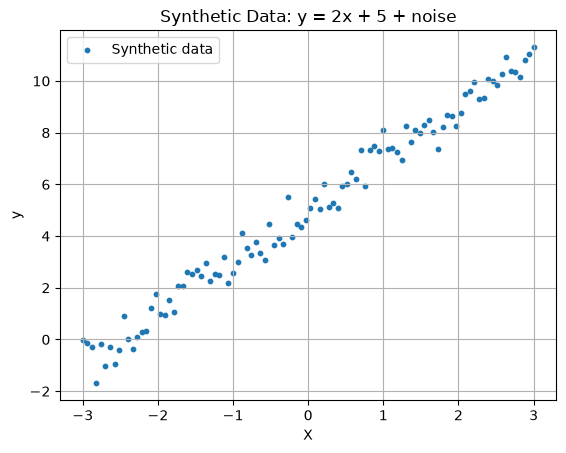

In [ ]:

# ── Generate synthetic data: y = 2x + 5 + noise ──────────────────────────────

# Fix random seed so results are reproducible every run
torch.manual_seed(42)

# Create 100 evenly spaced x values between -3 and 3
# unsqueeze(1) reshapes from (100,) → (100, 1) so it works with nn.Linear
X = torch.linspace(-3, 3, 100).unsqueeze(1)

# Ground truth: y = 2x + 5 with small Gaussian noise (std=0.5)
# The model will try to learn these exact weight (2) and bias (5)
y = 2 * X + 5 + torch.randn_like(X) * 0.5

# Visualize the raw dataset before training
plt.scatter(X.numpy(), y.numpy(), s=10, label='Synthetic data')
plt.title('Synthetic Data: y = 2x + 5 + noise')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

# ── Define model, loss function, and optimizer ────────────────────────────────

# nn.Linear(1, 1): single input feature → single output
#   internally holds a learnable weight matrix and bias vector
#   computes: output = weight * input + bias
model = nn.Linear(in_features=1, out_features=1)

# MSELoss: Mean Squared Error — standard loss for regression
#   MSE = (1/n) * Σ(y_pred - y_true)²
#   penalises large errors more than small ones
loss_fn = nn.MSELoss()

# SGD (Stochastic Gradient Descent): classic optimizer
#   updates weights by: w = w - lr * gradient
#   lr=0.05 is the learning rate (step size per update)
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

# Show the randomly initialised starting values (before any training)
print(f'Initial weight: {model.weight.item():.4f}, bias: {model.bias.item():.4f}')


Initial weight: 0.1564, bias: -0.8799


---
## Q8: Training Loop
Forward pass → Loss computation → Backward pass → Optimizer step

In [ ]:

# ── Training Loop (Q8) ────────────────────────────────────────────────────────
# One full pass through ALL training data = 1 epoch
EPOCHS = 200
losses = []   # store loss per epoch to plot later

for epoch in range(EPOCHS):

    # ── Step 1: Forward Pass ──────────────────────────────────────────────────
    # Pass input X through the model to get predictions
    # model computes: y_pred = weight * X + bias
    y_pred = model(X)

    # ── Step 2: Compute Loss ──────────────────────────────────────────────────
    # Compare predictions with true labels using MSE
    # A lower loss means the model's predictions are closer to reality
    loss = loss_fn(y_pred, y)
    losses.append(loss.item())   # .item() extracts the scalar Python float

    # ── Step 3: Backward Pass (Backpropagation) ───────────────────────────────
    # Zero out any gradients accumulated from the previous iteration
    # (PyTorch accumulates gradients by default, so we must reset each step)
    optimizer.zero_grad()

    # Compute gradients of the loss w.r.t. every learnable parameter
    # PyTorch traces the computation graph and applies the chain rule
    loss.backward()

    # ── Step 4: Optimizer Step (Weight Update) ────────────────────────────────
    # Use the computed gradients to nudge weights in the direction that reduces loss
    # SGD update rule: w = w - lr * dL/dw
    optimizer.step()

    # Print progress every 40 epochs to track learning
    if (epoch + 1) % 40 == 0:
        print(f'Epoch [{epoch+1:>3}/{EPOCHS}]  Loss: {loss.item():.4f}  '
              f'w: {model.weight.item():.4f}  b: {model.bias.item():.4f}')

# After training, learnt values should be close to w≈2.0 and b≈5.0
print(f'\nFinal weight: {model.weight.item():.4f}  (target ≈ 2.0)')
print(f'Final bias  : {model.bias.item():.4f}  (target ≈ 5.0)')


Epoch [ 40/200]  Loss: 0.2501  w: 1.9951  b: 4.9425
Epoch [ 80/200]  Loss: 0.2407  w: 1.9951  b: 5.0286
Epoch [120/200]  Loss: 0.2407  w: 1.9951  b: 5.0299
Epoch [160/200]  Loss: 0.2407  w: 1.9951  b: 5.0299
Epoch [200/200]  Loss: 0.2407  w: 1.9951  b: 5.0299

Final weight: 1.9951  (target ≈ 2.0)
Final bias  : 5.0299  (target ≈ 5.0)


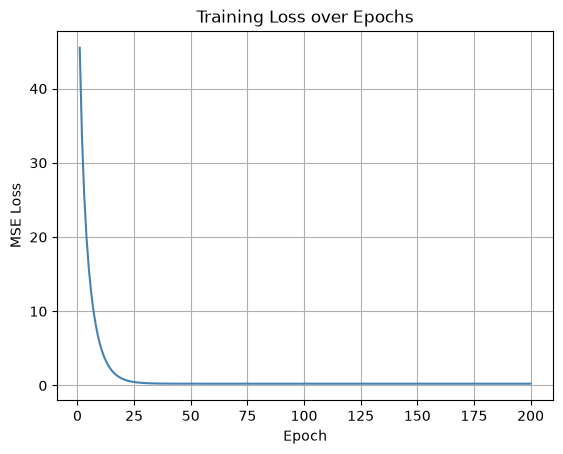

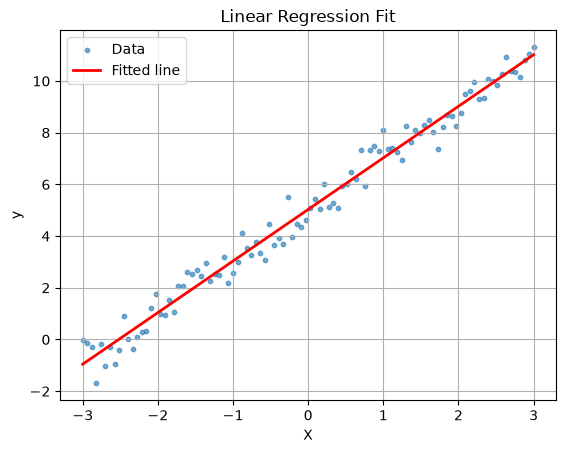

In [ ]:

# ── Plot 1: Training Loss Curve ───────────────────────────────────────────────
# A decreasing curve confirms the model is learning (loss going down each epoch)
plt.plot(range(1, EPOCHS + 1), losses, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

# ── Plot 2: Fitted Regression Line ────────────────────────────────────────────
# torch.no_grad() disables gradient tracking — we only need predictions, not gradients
with torch.no_grad():
    y_fit = model(X)   # run a clean forward pass to get the fitted values

# Scatter = raw data points, line = the model's learnt linear relationship
plt.scatter(X.numpy(), y.numpy(), s=10, label='Data', alpha=0.6)
plt.plot(X.numpy(), y_fit.numpy(), color='red', lw=2, label='Fitted line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True)
plt.show()


---
## Bonus: AND, OR, XOR Gates using Neural Networks

| Gate | Learnable with single layer? |
|------|------------------------------|
| AND  | ✅ Yes (linearly separable)  |
| OR   | ✅ Yes (linearly separable)  |
| XOR  | ❌ No → needs hidden layer   |

In [ ]:

# ── Truth Table Inputs for Logic Gates ───────────────────────────────────────
# All possible combinations of two binary inputs: (0,0), (0,1), (1,0), (1,1)
inputs = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])

# Expected outputs for each gate (shape: 4×1 for BCELoss compatibility)
# AND: only TRUE when BOTH inputs are 1
and_labels = torch.tensor([[0.], [0.], [0.], [1.]])

# OR:  TRUE when AT LEAST ONE input is 1
or_labels  = torch.tensor([[0.], [1.], [1.], [1.]])

# XOR: TRUE when inputs are DIFFERENT (cannot be solved with a single linear layer!)
xor_labels = torch.tensor([[0.], [1.], [1.], [0.]])


In [ ]:

# ── Helper Functions ──────────────────────────────────────────────────────────

def train_gate(model, X, y, epochs=2000, lr=0.1):
    """Run the training loop for a logic gate model.
    
    Uses Binary Cross-Entropy loss because outputs are probabilities (0–1).
    Adam optimizer adapts the learning rate per parameter — converges faster
    than plain SGD for small datasets like logic gates.
    """
    # BCELoss: Binary Cross-Entropy — measures how far predicted probability
    # is from the true binary label (0 or 1)
    loss_fn = nn.BCELoss()

    # Adam: adaptive optimizer that maintains per-parameter learning rates
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for _ in range(epochs):
        # Forward pass: model outputs a probability via Sigmoid activation
        pred = model(X)

        # Loss: how wrong is the predicted probability vs the true label
        loss = loss_fn(pred, y)

        # Standard backward + update cycle
        optimizer.zero_grad()   # clear old gradients
        loss.backward()         # compute new gradients
        optimizer.step()        # apply weight update

    return model


def evaluate_gate(model, X, y, name):
    """Print the prediction table and accuracy for a trained gate model."""

    # torch.no_grad() prevents gradient computation — we only need inference
    with torch.no_grad():
        probs = model(X)                      # raw probability output (Sigmoid)
        preds = (probs >= 0.5).float()        # threshold 0.5 → binary 0 or 1

    # Fraction of correctly predicted rows
    acc = (preds == y).float().mean().item()

    print(f'\n── {name} Gate ──────────────────────')
    for i, (inp, prob, pred, target) in enumerate(zip(X, probs, preds, y)):
        print(f'  {int(inp[0].item())} {int(inp[1].item())} → '
              f'prob={prob.item():.3f}  pred={int(pred.item())}  target={int(target.item())}')
    print(f'  Accuracy: {acc*100:.0f}%')


In [8]:

# ── AND Gate ──────────────────────────────────────────────────────────────────
# AND is linearly separable → a single Linear layer is enough to learn it.
# Architecture: 2 inputs → Linear(2,1) → Sigmoid → 1 output probability
# The Sigmoid squashes any real number into (0, 1) — interpreted as probability
torch.manual_seed(0)
and_model = nn.Sequential(
    nn.Linear(2, 1),   # learns a weighted sum of the two inputs + bias
    nn.Sigmoid()       # squashes output to probability range [0, 1]
)
# Train using the reusable helper (BCELoss + Adam for 2000 epochs)
and_model = train_gate(and_model, inputs, and_labels)

# Print predictions vs targets for all 4 input combinations
evaluate_gate(and_model, inputs, and_labels, 'AND')



── AND Gate ──────────────────────
  0 0 → prob=0.000  pred=0  target=0
  0 1 → prob=0.001  pred=0  target=0
  1 0 → prob=0.001  pred=0  target=0
  1 1 → prob=0.999  pred=1  target=1
  Accuracy: 100%


In [9]:

# ── OR Gate ───────────────────────────────────────────────────────────────────
# OR is also linearly separable → same single-layer architecture as AND.
# The model only needs to learn a different decision boundary (hyperplane)
# that separates (0,0) from all other input combinations.
torch.manual_seed(0)
or_model = nn.Sequential(
    nn.Linear(2, 1),   # learnable weights for each input + bias
    nn.Sigmoid()       # output is P(output=1 | inputs)
)
# Train with the same helper — only the labels differ from AND
or_model = train_gate(or_model, inputs, or_labels)

# Print predictions vs targets for all 4 input combinations
evaluate_gate(or_model, inputs, or_labels, 'OR')



── OR Gate ──────────────────────
  0 0 → prob=0.002  pred=0  target=0
  0 1 → prob=0.999  pred=1  target=1
  1 0 → prob=0.999  pred=1  target=1
  1 1 → prob=1.000  pred=1  target=1
  Accuracy: 100%


In [10]:

# ── XOR Gate ──────────────────────────────────────────────────────────────────
# XOR is NOT linearly separable — no single straight line can separate
# (0,0),(1,1)=0 from (0,1),(1,0)=1.  A hidden layer is required to learn
# a non-linear decision boundary.
#
# Architecture:
#   Input(2) → Linear(2→4) → ReLU → Linear(4→1) → Sigmoid → Output(1)
#   - Hidden layer (4 neurons): creates intermediate representations
#   - ReLU: introduces non-linearity  (ReLU(x) = max(0, x))
#   - Output layer: collapses hidden features to a single probability
torch.manual_seed(0)
xor_model = nn.Sequential(
    nn.Linear(2, 4),   # hidden layer — maps 2 inputs to 4 hidden features
    nn.ReLU(),         # non-linear activation: allows learning XOR boundary
    nn.Linear(4, 1),   # output layer — collapses 4 features to 1 probability
    nn.Sigmoid()       # squashes to [0, 1] for binary classification
)
# XOR needs more epochs (5000) and a smaller lr (0.05) to converge reliably
xor_model = train_gate(xor_model, inputs, xor_labels, epochs=5000, lr=0.05)

# Print predictions vs targets for all 4 input combinations
evaluate_gate(xor_model, inputs, xor_labels, 'XOR')



── XOR Gate ──────────────────────
  0 0 → prob=0.000  pred=0  target=0
  0 1 → prob=1.000  pred=1  target=1
  1 0 → prob=1.000  pred=1  target=1
  1 1 → prob=0.000  pred=0  target=0
  Accuracy: 100%


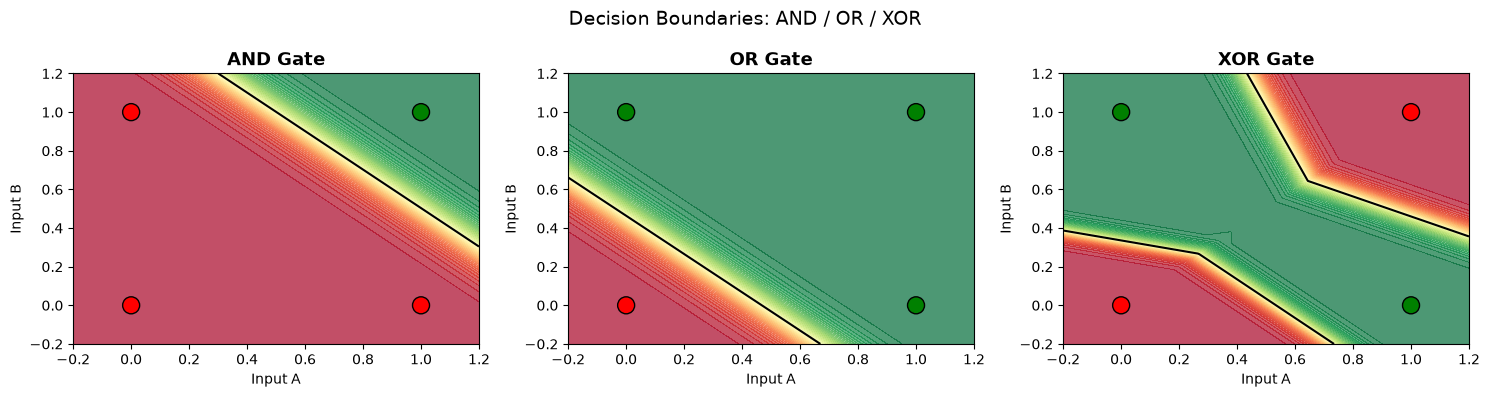

In [ ]:

# ── Decision Boundary Visualization ───────────────────────────────────────────
# A decision boundary is the line (or curve) where the model's output probability = 0.5
# Points on one side → predicted 0; points on the other side → predicted 1.
# AND/OR have straight-line boundaries (linear models).
# XOR has a curved boundary (only possible because of the hidden layer + ReLU).

def plot_decision_boundary(model, title, ax):
    """Shade the 2D input space by predicted probability and draw the 0.5 boundary."""
    # Create a dense grid covering the entire input space [−0.2, 1.2] × [−0.2, 1.2]
    xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 200), np.linspace(-0.2, 1.2, 200))

    # Stack grid coordinates into shape (40000, 2) and convert to tensor
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    # Run inference on every grid point (no gradients needed)
    with torch.no_grad():
        zz = model(grid).reshape(xx.shape).numpy()   # reshape back to 200×200

    # Colour the background: green = high probability (→1), red = low (→0)
    ax.contourf(xx, yy, zz, levels=50, cmap='RdYlGn', alpha=0.7)

    # Draw the decision boundary line exactly where probability = 0.5
    ax.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=1.5)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Input A')
    ax.set_ylabel('Input B')


# Create 1 row × 3 columns of subplots — one per gate
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for model, labels, title, ax in [
    (and_model, and_labels, 'AND Gate', axes[0]),
    (or_model,  or_labels,  'OR Gate',  axes[1]),
    (xor_model, xor_labels, 'XOR Gate', axes[2]),
]:
    # Draw the shaded background and decision boundary
    plot_decision_boundary(model, title, ax)

    # Overlay the 4 truth-table points:
    #   red  = expected output 0 (false)
    #   green = expected output 1 (true)
    colors = ['red' if l == 0 else 'green' for l in labels.squeeze().tolist()]
    ax.scatter(inputs[:, 0].numpy(), inputs[:, 1].numpy(),
               c=colors, s=150, zorder=5, edgecolors='black')
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.2)

plt.suptitle('Decision Boundaries: AND / OR / XOR', fontsize=14)
plt.tight_layout()
plt.show()
